# Interpretable Bankruptcy Risk Modeling
### Saloni Jain

This notebook trains interpretable classifiers on the bankruptcy dataset, evaluates **class 1** performance, compares four global-interpretation approaches (Decision Tree importance, Random Forest importance, SHAP TreeExplainer, SHAP KernelExplainer), and answers the assignment's discussion questions.

**Outcome definition:** `D = 0` means failed/bankrupt and `D = 1` means healthy. Every class-1 performance number and SHAP explanation below therefore refers to the **healthy** class, per the assignment's own definition of `D`.

## Setup

Model selection is done only on the training set using 5-fold cross-validation. The held-out test set is then used for final evaluation and interpretation. Random seeds are fixed so the results can be reproduced.

In [1]:
# If any of the following packages are missing, please install them before proceeding.
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# load data and partition into train and test sets
# please run the following code exactly to ensure reproducibility
data = pd.read_csv("../data/bankruptcy.csv")
Y = data["D"]
X = data.drop(columns=["D"])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)
# this cell should return (105, 24) (105,) (27, 24) (27,)

(105, 24) (105,) (27, 24) (27,)


In [3]:
# Basic data-quality checks before modeling
print(f"Rows: {len(data)}, predictors: {X.shape[1]}")
print(f"Missing values: {int(data.isna().sum().sum())}")
print(f"Duplicate rows: {int(data.duplicated().sum())}")

class_counts = pd.DataFrame({
    "full_data": Y.value_counts().sort_index(),
    "train": Y_train.value_counts().sort_index(),
    "test": Y_test.value_counts().sort_index(),
})
class_counts.index = ["Failed / bankrupt (0)", "Healthy (1)"]
display(class_counts)

Rows: 132, predictors: 24
Missing values: 0
Duplicate rows: 0


,full_data,train,test
Failed / bankrupt (0),66,48,18
Healthy (1),66,57,9


The supplied split has 105 training observations and 27 test observations. The test set contains 18 failed firms and only 9 healthy firms, so every test-set metric below is based on a small number of cases and should be read as an estimate rather than a precise, stable benchmark.

---
## Model performance and global interpretation

### 1A. Decision Tree

I used 5-fold cross-validation on the training data to select the tree depth. The scoring metric is F1 for class 1 because the assignment specifically asks for class-1 performance. Limiting the depth is also helpful because a fully grown tree could overfit this small training set.

In [4]:
from sklearn.model_selection import GridSearchCV

param_grid = {"max_depth": [2, 3, 4, 5, 6, None]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring="f1")
dt_grid.fit(X_train, Y_train)
print("Best max_depth selected by CV:", dt_grid.best_params_, "| CV F1:", round(dt_grid.best_score_, 3))

dt_clf = dt_grid.best_estimator_

# Performance on the held-out test set, focusing on class 1 (healthy firms, per D's definition: D=0 failed, D=1 healthy)
Y_pred_dt = dt_clf.predict(X_test)
print("\nDecision Tree performance on test set:")
dt_report = pd.DataFrame(
    classification_report(
        Y_test,
        Y_pred_dt,
        target_names=["Failed (0)", "Healthy (1)"],
        output_dict=True,
    )
).T
dt_report.loc["accuracy", ["precision", "recall"]] = np.nan
display(
    dt_report.style
    .set_caption("Decision Tree Classification Report")
    .format({"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}", "support": "{:.0f}"}, na_rep="")
)

dt_confusion = pd.DataFrame(
    confusion_matrix(Y_test, Y_pred_dt),
    index=["Actual: Failed (0)", "Actual: Healthy (1)"],
    columns=["Predicted: Failed (0)", "Predicted: Healthy (1)"],
)
display(dt_confusion.style.set_caption("Decision Tree Confusion Matrix"))

Best max_depth selected by CV: {'max_depth': 2} | CV F1: 0.778

Decision Tree performance on test set:


,precision,recall,f1-score,support
Failed (0),0.789,0.833,0.811,18
Healthy (1),0.625,0.556,0.588,9
accuracy,,,0.741,1
macro avg,0.707,0.694,0.700,27
weighted avg,0.735,0.741,0.737,27


,Predicted: Failed (0),Predicted: Healthy (1)
Actual: Failed (0),15,3
Actual: Healthy (1),4,5


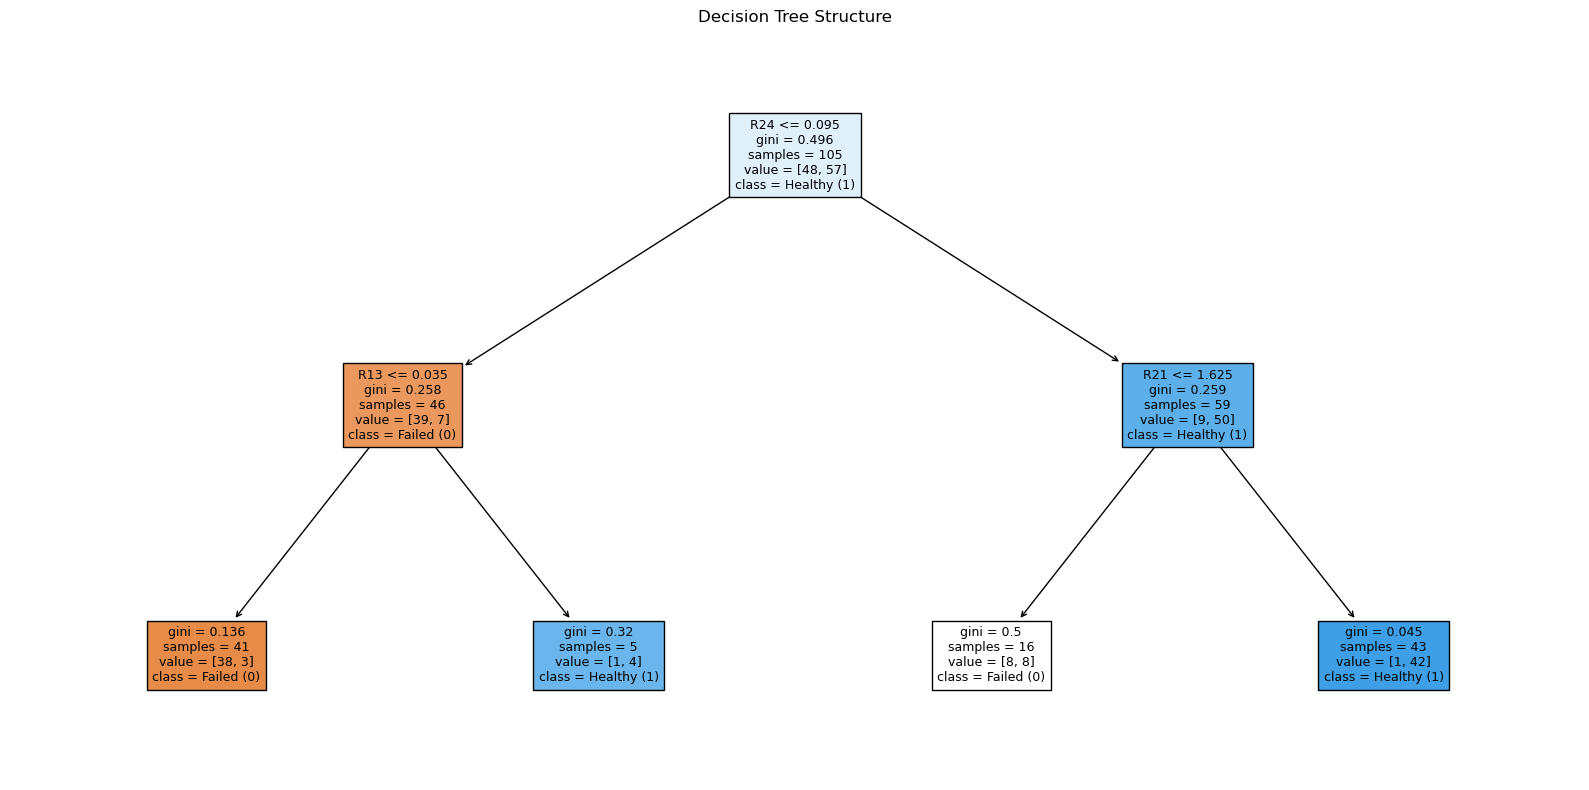

Decision Tree feature importances (non-zero only):
R24    0.714017
R21    0.151451
R13    0.134532
dtype: float64


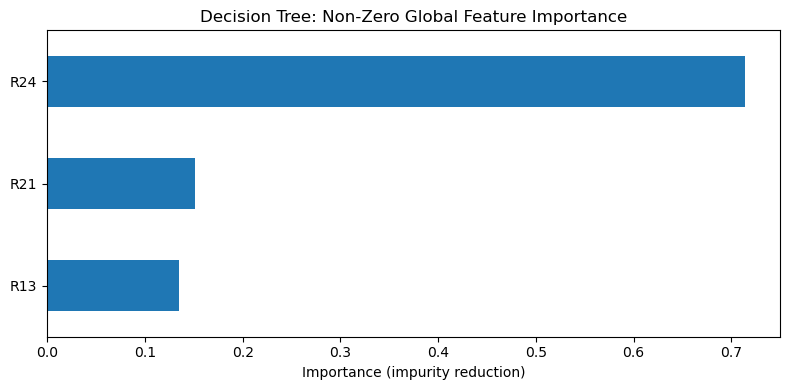

In [5]:
# Visualize the fitted decision tree.
plt.figure(figsize=(16, 8))
plot_tree(
    dt_clf,
    feature_names=X.columns,
    class_names=["Failed (0)", "Healthy (1)"],
    filled=True,
    fontsize=9,
)
plt.title("Decision Tree Structure")
plt.tight_layout()
plt.show()

# Global importance is the total impurity reduction credited to each feature.
dt_importances = pd.Series(
    dt_clf.feature_importances_, index=X.columns
).sort_values(ascending=False)

# A depth-2 tree uses only three split features, so showing zero-importance
# variables as part of a "top 10" list would be misleading.
dt_nonzero = dt_importances[dt_importances > 0]
print("Decision Tree feature importances (non-zero only):")
print(dt_nonzero)

plt.figure(figsize=(8, 4))
dt_nonzero.sort_values().plot(kind="barh")
plt.title("Decision Tree: Non-Zero Global Feature Importance")
plt.xlabel("Importance (impurity reduction)")
plt.tight_layout()
plt.show()

**Decision Tree interpretation.** Cross-validation selects a depth-2 tree (CV F1 of about 0.778). On the held-out set it reaches 0.741 accuracy; for the healthy class, precision is 0.625, recall is 0.556, and F1 is 0.588. Because a depth-2 tree has only 3 internal splits, it can assign non-zero importance to at most 3 ratios: **R24 (WCFO/DEBTS)**, **R21 (ASSETS/DEBTS)**, and **R13 (INC/SALES)**, with R24 dominating. This makes the tree very easy to explain, but the modest class-1 recall and its reliance on only 3 of 24 ratios suggest it is a simple approximation rather than the strongest available predictor. Its "importance ranking" reflects the tree's limited capacity, not proof that the other 21 ratios are irrelevant.

### 1B. Random Forest

The forest is tuned the same way, via 5-fold cross-validation on the training data, this time over `n_estimators`, `max_depth`, and `min_samples_leaf`. Its global feature importance is mean decrease in impurity, averaged across every tree in the ensemble.

In [6]:
rf_param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [3, 5, None],
    "min_samples_leaf": [1, 3]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, scoring="f1")
rf_grid.fit(X_train, Y_train)
print("Best RF params selected by CV:", rf_grid.best_params_, "| CV F1:", round(rf_grid.best_score_, 3))

rf_clf = rf_grid.best_estimator_

# Performance on the held-out test set, focusing on class 1 (healthy firms, per D's definition)
Y_pred_rf = rf_clf.predict(X_test)
print("\nRandom Forest performance on test set:")
rf_report = pd.DataFrame(
    classification_report(
        Y_test,
        Y_pred_rf,
        target_names=["Failed (0)", "Healthy (1)"],
        output_dict=True,
    )
).T
rf_report.loc["accuracy", ["precision", "recall"]] = np.nan
display(
    rf_report.style
    .set_caption("Random Forest Classification Report")
    .format({"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}", "support": "{:.0f}"}, na_rep="")
)

rf_confusion = pd.DataFrame(
    confusion_matrix(Y_test, Y_pred_rf),
    index=["Actual: Failed (0)", "Actual: Healthy (1)"],
    columns=["Predicted: Failed (0)", "Predicted: Healthy (1)"],
)
display(rf_confusion.style.set_caption("Random Forest Confusion Matrix"))

Best RF params selected by CV: {'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 100} | CV F1: 0.868

Random Forest performance on test set:


,precision,recall,f1-score,support
Failed (0),0.938,0.833,0.882,18
Healthy (1),0.727,0.889,0.800,9
accuracy,,,0.852,1
macro avg,0.832,0.861,0.841,27
weighted avg,0.867,0.852,0.855,27


,Predicted: Failed (0),Predicted: Healthy (1)
Actual: Failed (0),15,3
Actual: Healthy (1),1,8


Random Forest feature importances (top 10):


,Importance
R18,0.141819
R14,0.114542
R21,0.110531
R24,0.079162
R23,0.068077
R15,0.066085
R9,0.059181
R17,0.057232
R13,0.036107
R10,0.032868


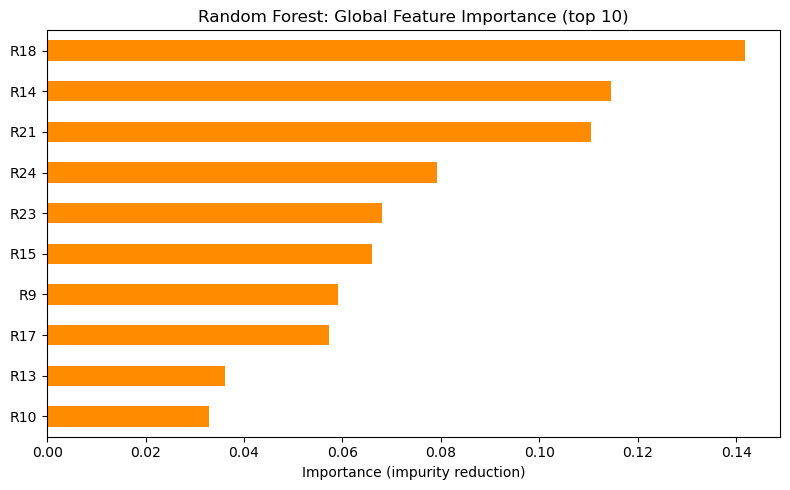

In [7]:
rf_importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Random Forest feature importances (top 10):")
display(rf_importances.head(10).to_frame(name="Importance"))

plt.figure(figsize=(8, 5))
rf_importances.head(10).sort_values().plot(kind="barh", color="darkorange")
plt.title("Random Forest: Global Feature Importance (top 10)")
plt.xlabel("Importance (impurity reduction)")
plt.tight_layout()
plt.show()

**Random Forest interpretation.** Cross-validation selects 100 trees, max depth 5, and min leaf size 3 (CV F1 of about 0.868). On the held-out set the model reaches 0.852 accuracy; for the healthy class, precision is 0.727, recall is 0.889, and F1 is 0.800. This is materially better than the single tree, although the test set is too small for a definitive comparison. The leading ratios are **R18 (INCDEP/DEBTS)**, **R14 (INC/ASSETS)**, **R21 (ASSETS/DEBTS)**, **R24 (WCFO/DEBTS)**, and **R23 (WCFO/ASSETS)**. R24 and R21 overlap with the Decision Tree's features, but their order changes. R13, which is third in the Decision Tree, falls to rank 9 in the Random Forest. This shows that global importance depends partly on the fitted model.

### 1C. SHAP TreeExplainer

TreeExplainer is designed for tree-based models. Here, I calculate SHAP values for class 1 (healthy) on the 27 test observations. I then take the mean absolute SHAP value for each feature to create a global importance ranking. The absolute value shows the size of a feature's contribution, while the summary plot also shows its direction.

SHAP (TreeExplainer) global importance for class 1 -- healthy -- (top 10):


,Mean |SHAP value|
R21,0.065912
R18,0.064446
R14,0.052759
R24,0.036302
R15,0.034850
R23,0.032432
R17,0.030285
R9,0.027382
R10,0.018303
R13,0.015572


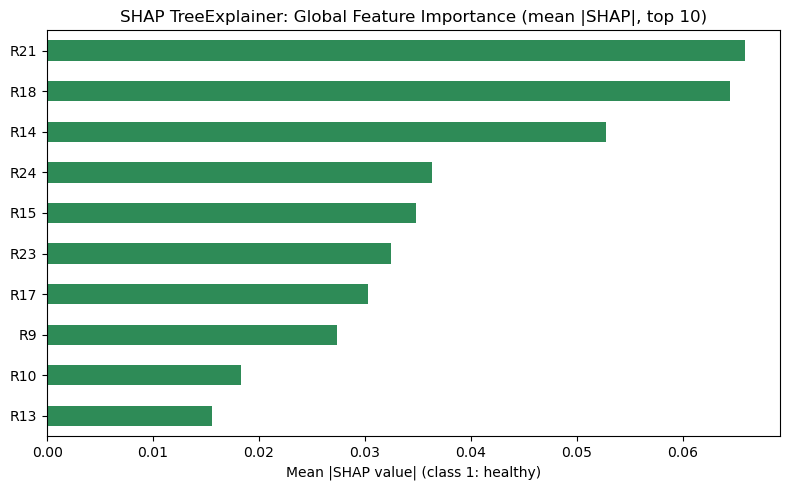

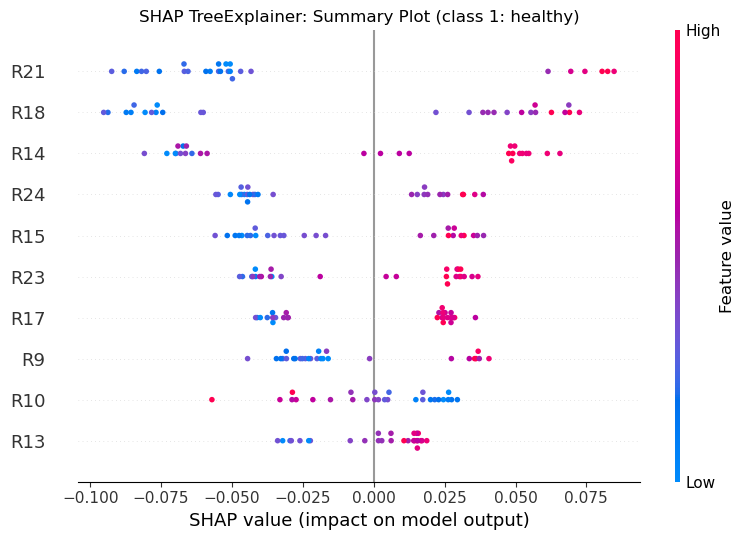

In [8]:
def class_one_shap_values(raw_values):
    # shap's return format for a binary classifier has changed across versions:
    # older versions return a list of two (n_obs, n_features) arrays, one per class;
    # newer versions return a single (n_obs, n_features, n_classes) array.
    # This helper normalizes either format to the class-1 (healthy) array so the rest
    # of the code works regardless of which shap version is installed.
    if isinstance(raw_values, list):
        return np.asarray(raw_values[1])
    values = np.asarray(raw_values)
    if values.ndim == 3:
        return values[:, :, 1]
    return values

tree_explainer = shap.TreeExplainer(rf_clf)
tree_shap_raw = tree_explainer.shap_values(X_test)
tree_shap_values_class1 = class_one_shap_values(tree_shap_raw)

tree_shap_importance = pd.Series(
    np.abs(tree_shap_values_class1).mean(axis=0), index=X.columns
).sort_values(ascending=False)

print("SHAP (TreeExplainer) global importance for class 1 -- healthy -- (top 10):")
display(tree_shap_importance.head(10).to_frame(name="Mean |SHAP value|"))

plt.figure(figsize=(8, 5))
tree_shap_importance.head(10).sort_values().plot(kind="barh", color="seagreen")
plt.title("SHAP TreeExplainer: Global Feature Importance (mean |SHAP|, top 10)")
plt.xlabel("Mean |SHAP value| (class 1: healthy)")
plt.tight_layout()
plt.show()

# SHAP's own summary plot, which additionally shows the direction of each feature's effect
# (red = high feature value, blue = low feature value) alongside its magnitude
shap.summary_plot(tree_shap_values_class1, X_test, feature_names=X.columns, max_display=10, show=False)
plt.title("SHAP TreeExplainer: Summary Plot (class 1: healthy)")
plt.tight_layout()
plt.show()

**SHAP TreeExplainer interpretation.** The leading global contributors are **R21, R18, R14, R24, and R15**. This largely confirms the Random Forest impurity ranking (Spearman correlation of about 0.97), although the exact order changes. In the summary plot, points to the right increase the model's healthy-class output relative to its baseline and points to the left decrease it; color encodes the observed ratio value. The direction shown here is an association learned by this fitted model, not evidence that changing a ratio would cause the firm's actual status to change.

### 1D. SHAP KernelExplainer

KernelExplainer is model-agnostic, so it can explain the Random Forest without using its tree structure. It requires a prediction function and a background dataset. I use 50 training observations as the background and explain the same 27 test observations. A fixed seed and 200 coalition samples make the approximation reproducible and reasonably fast.

SHAP (KernelExplainer) global importance for class 1 -- healthy -- (top 10):


,Mean |SHAP value|
R18,0.061456
R21,0.061137
R14,0.048270
R24,0.030797
R15,0.030512
R23,0.028776
R17,0.026425
R9,0.022175
R10,0.011672
R4,0.011649


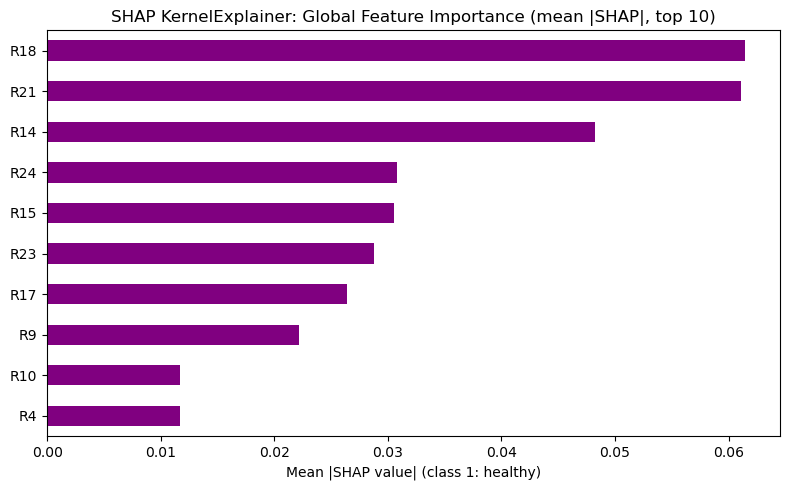

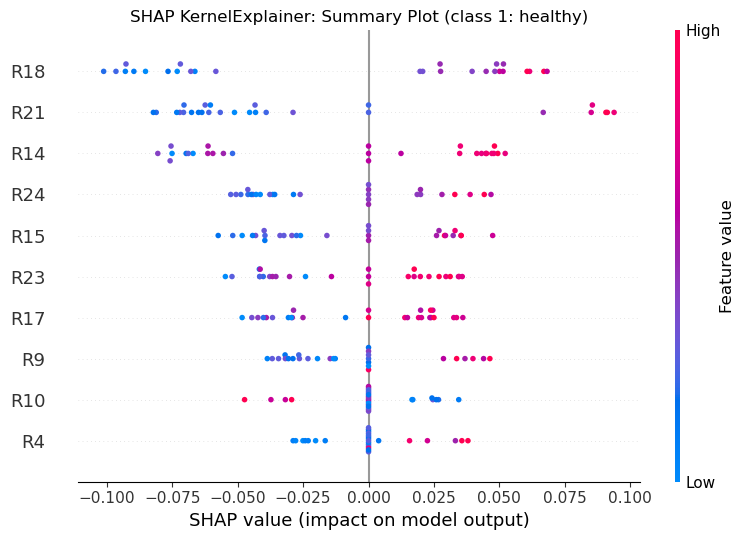

In [9]:
# Fix the random seed used by KernelExplainer's coalition sampling.
np.random.seed(42)
background = shap.sample(X_train, 50, random_state=42)


def predict_healthy(values):
    frame = pd.DataFrame(values, columns=X.columns)
    return rf_clf.predict_proba(frame)[:, 1]


kernel_explainer = shap.KernelExplainer(predict_healthy, background)
kernel_shap_values = kernel_explainer.shap_values(
    X_test, nsamples=200, silent=True
)

kernel_shap_importance = pd.Series(
    np.abs(kernel_shap_values).mean(axis=0), index=X.columns
).sort_values(ascending=False)

print("SHAP (KernelExplainer) global importance for class 1 -- healthy -- (top 10):")
display(kernel_shap_importance.head(10).to_frame(name="Mean |SHAP value|"))

plt.figure(figsize=(8, 5))
kernel_shap_importance.head(10).sort_values().plot(kind="barh", color="purple")
plt.title("SHAP KernelExplainer: Global Feature Importance (mean |SHAP|, top 10)")
plt.xlabel("Mean |SHAP value| (class 1: healthy)")
plt.tight_layout()
plt.show()

shap.summary_plot(
    kernel_shap_values,
    X_test,
    feature_names=X.columns,
    max_display=10,
    show=False,
)
plt.title("SHAP KernelExplainer: Summary Plot (class 1: healthy)")
plt.tight_layout()
plt.show()

**SHAP KernelExplainer interpretation.** KernelExplainer identifies the same main group as TreeExplainer: **R18, R21, R14, R24, and R15**, although their exact order changes slightly. This agreement is a useful consistency check because KernelExplainer does not use the Random Forest's tree structure. However, KernelExplainer is still an approximation, so its exact values depend on the background data and number of samples.

---
## Cross-method interpretation consistency

The methods use different importance scales, so I compare their feature rankings and Spearman rank correlations instead of comparing the raw importance numbers directly.

In [10]:
from scipy.stats import spearmanr

importance_comparison = pd.concat(
    [
        dt_importances.rename("Decision Tree MDI"),
        rf_importances.rename("Random Forest MDI"),
        tree_shap_importance.rename("SHAP-TreeExplainer"),
        kernel_shap_importance.rename("SHAP-KernelExplainer"),
    ],
    axis=1,
).fillna(0)

rank_comparison = importance_comparison.rank(
    axis=0, ascending=False, method="min"
)
print("Feature ranks (1 = most important), ordered by Random Forest rank:")
display(rank_comparison.sort_values("Random Forest MDI").head(10))

methods = importance_comparison.columns.tolist()
corr_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)
for first_method in methods:
    for second_method in methods:
        corr_matrix.loc[first_method, second_method] = spearmanr(
            importance_comparison[first_method],
            importance_comparison[second_method],
        ).correlation

print("\nSpearman rank correlation across all 24 ratios:")
display(corr_matrix.round(3))

# Show only features with positive importance. The Decision Tree has only three.
top_features = {}
for method in methods:
    ranked = importance_comparison[method].sort_values(ascending=False)
    top_features[method] = list(ranked[ranked > 0].head(5).index)

print("\nTop features by method (non-zero only):")
for method, features in top_features.items():
    print(f"  {method}: {features}")

common_features = set.intersection(
    *[set(features) for features in top_features.values()]
)
print("\nFeatures appearing in every method's leading group:", common_features)

Feature ranks (1 = most important), ordered by Random Forest rank:


,Decision Tree MDI,Random Forest MDI,SHAP-TreeExplainer,SHAP-KernelExplainer
R18,4.0,1.0,2.0,1.0
R14,4.0,2.0,3.0,3.0
R21,2.0,3.0,1.0,2.0
R24,1.0,4.0,4.0,4.0
R23,4.0,5.0,6.0,6.0
R15,4.0,6.0,5.0,5.0
R9,4.0,7.0,8.0,8.0
R17,4.0,8.0,7.0,7.0
R13,3.0,9.0,10.0,11.0
R10,4.0,10.0,9.0,9.0



Spearman rank correlation across all 24 ratios:


,Decision Tree MDI,Random Forest MDI,SHAP-TreeExplainer,SHAP-KernelExplainer
Decision Tree MDI,1.000,0.398,0.418,0.384
Random Forest MDI,0.398,1.000,0.967,0.966
SHAP-TreeExplainer,0.418,0.967,1.000,0.974
SHAP-KernelExplainer,0.384,0.966,0.974,1.000



Top features by method (non-zero only):
  Decision Tree MDI: ['R24', 'R21', 'R13']
  Random Forest MDI: ['R18', 'R14', 'R21', 'R24', 'R23']
  SHAP-TreeExplainer: ['R21', 'R18', 'R14', 'R24', 'R15']
  SHAP-KernelExplainer: ['R18', 'R21', 'R14', 'R24', 'R15']

Features appearing in every method's leading group: {'R21', 'R24'}


### Findings

**The interpretations are partly consistent.** The Random Forest importance, TreeExplainer, and KernelExplainer agree strongly. Their rank correlations are about **0.97**, and they repeatedly identify **R18, R21, R14, and R24** as important. The two SHAP methods also produce the same top-five group, with only a small change in order.

The Decision Tree is the main exception. It uses only **R24, R21, and R13**, because the selected depth-2 tree has only three splits. This does not necessarily mean the other ratios are unimportant; it means that this particular small tree did not use them.

The difference also comes from how importance is defined. Decision Tree and Random Forest impurity importances measure how much a feature reduces impurity at model splits. SHAP measures how much a feature contributes to predictions relative to a baseline. Related accounting ratios can also share importance because several of them use the same income, asset, debt, or working-capital values.

Based on these results, **R21 and R24 have the strongest cross-method support**, with R18 and R14 also strongly supported by the Random Forest and both SHAP methods. I would not claim that one exact ranking is the only correct interpretation.

---
## Executive communication

### Findings

To present the results to executives, I would focus on the main message instead of showing four long feature rankings. The Random Forest performed better than the single Decision Tree on this test set, and the most consistent drivers relate to **profitability and the ability of assets, earnings, and working capital from operations to cover debt**.

The clearest ratios are **R21 (ASSETS/DEBTS), R24 (WCFO/DEBTS), R18 (INCDEP/DEBTS), and R14 (INC/ASSETS)**. In the SHAP summary plots for this test set, higher values of these ratios generally push the model toward the healthy class, while lower values push it toward the failed class. R21 and R24 are leading features across all four methods. R18 and R14 are strongly supported by the Random Forest and both SHAP methods. R13 is method-sensitive: it is prominent in the small Decision Tree but ranks much lower in the Random Forest and SHAP results.

The uncertainty also needs to be clear. The dataset contains only 132 firms, and the test set contains only 27 firms, including 9 healthy firms. Therefore, the performance and rankings should be treated as useful signals rather than precise facts.

I would use the model as a **screening tool**. It can help analysts decide which clients and financial areas need closer review, but it should not make an automatic investment or advisory decision by itself.

---
## Business recommendations

### Findings

The model identifies financial areas associated with bankruptcy risk, but it does not prove causality for an individual client. I would use the strongest consensus ratios from Question 3 to guide a review of the client's financial statements and then recommend actions that address the client's main weakness.

- **Improve working-capital-from-operations coverage of debt (R24):** accelerate receivables collection, manage inventory more efficiently, review supplier payment terms, and reduce avoidable operating expenses. These actions can increase the operating funds available to meet debt obligations.
- **Strengthen income-plus-depreciation coverage of debt (R18):** improve recurring earnings and review non-cash depreciation, capital and maintenance needs, and the size and structure of debt. Because R18 is income plus depreciation rather than actual cash flow, I would compare it with the client's cash-flow statement.
- **Improve asset coverage of debt (R21):** reduce excessive borrowing, refinance short-term obligations into more manageable maturities, sell non-core assets where appropriate, or consider additional equity financing.
- **Improve profitability relative to assets (R14):** review pricing, product mix, asset utilization, and recurring costs to improve sustainable returns rather than relying on one-time accounting gains.

I would not give every client the same plan. As a separate next step, clients could be grouped according to their main risk pattern, such as weak debt coverage, high leverage, or low profitability. This follows the main takeaway from the clustering homework: recommendations should be tailored to groups with similar needs. The client segments would still need to be created and validated in a separate analysis.

For each client, I would set measurable targets and monitor actual changes in operating funds, debt burden, profitability, and financial stability rather than focusing only on the model score.

---
## Final Conclusion and Limitations

The Random Forest is the stronger model in this exercise, with a class-1 F1 score of **0.800**, compared with **0.588** for the Decision Tree. Its built-in importance and both SHAP explainers point to the same general story: profitability and the coverage of debt by assets, income plus depreciation, and working capital from operations are the most important financial areas in the model.

The results should still be interpreted carefully. The dataset and test set are small, the analysis uses only one train/test split, related ratios may share importance, and KernelExplainer is an approximation. The sample contains manufacturing and retail firms, so the findings may not generalize to other industries. Feature importance explains what the fitted model uses, but it does not prove that changing a ratio will cause a firm to avoid bankruptcy.